# Кластеризация

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram

In [3]:
# Ссылка на датасет (можно использовать локальный файл)
url = "mall_customers_clustering.csv"
df = pd.read_csv(url, index_col=0)
df.head()

,CustomerID,Genre,Age,Income,Score
0,1,Male,19,15000,0.39
1,2,Male,21,15000,0.81
2,3,Female,20,16000,0.06
3,4,Female,23,16000,0.77
4,5,Female,31,17000,0.40


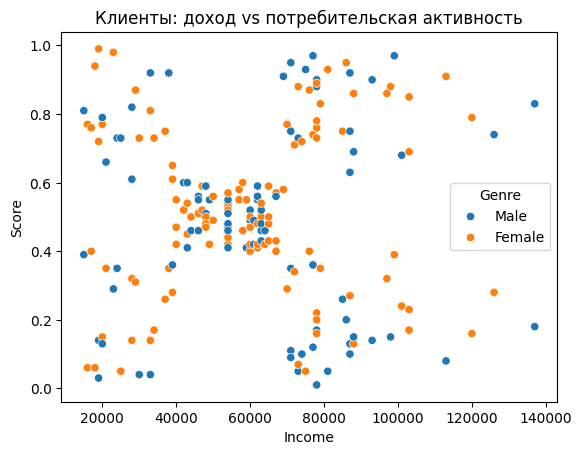

In [4]:
sns.scatterplot(x='Income', y='Score', data=df, hue='Genre')
plt.title('Клиенты: доход vs потребительская активность')
plt.show()

In [5]:
x = df.drop(["CustomerID"], axis=1)   # CustomerID не нужен
X = pd.get_dummies(x)                # Genre -> два столбца Genre_Female, Genre_Male
X.head()

,Age,Income,Score,Genre_Female,Genre_Male
0,19,15000,0.39,False,True
1,21,15000,0.81,False,True
2,20,16000,0.06,True,False
3,23,16000,0.77,True,False
4,31,17000,0.40,True,False


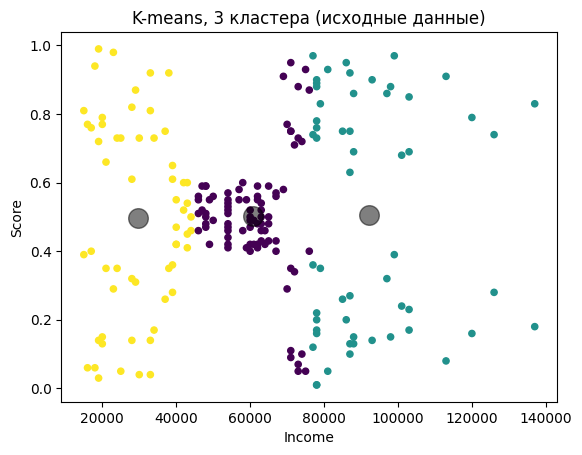

In [6]:
k_means = KMeans(n_clusters=3, random_state=42).fit(X)
y_kmeans = k_means.labels_
centers = k_means.cluster_centers_

plt.scatter(x.Income, x.Score, c=y_kmeans, s=20, cmap='viridis')
plt.scatter(centers[:, 1], centers[:, 2], c='black', s=200, alpha=0.5)
plt.title('K-means, 3 кластера (исходные данные)')
plt.xlabel('Income')
plt.ylabel('Score')
plt.show()

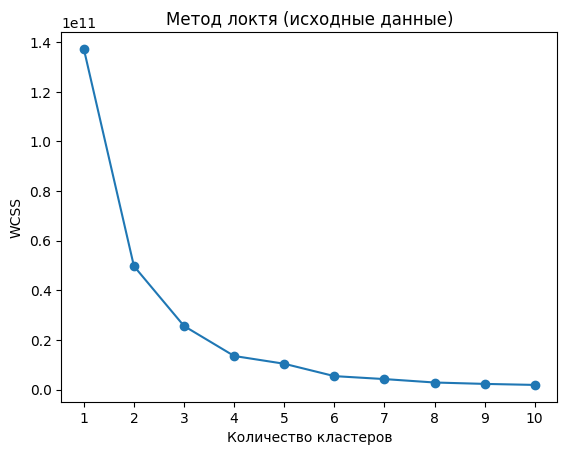

In [7]:
wcss = []
for i in range(1, 11):
    k_means = KMeans(n_clusters=i, random_state=42)
    k_means.fit(X)
    wcss.append(k_means.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.xticks(range(1, 11))
plt.xlabel('Количество кластеров')
plt.ylabel('WCSS')
plt.title('Метод локтя (исходные данные)')
plt.show()

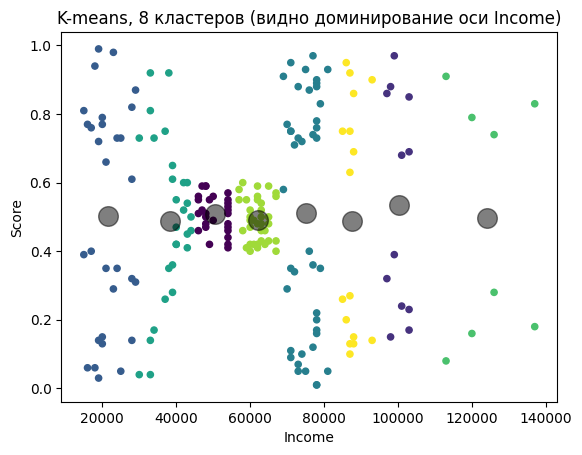

In [8]:
k_means_8 = KMeans(n_clusters=8, random_state=42).fit(X)
y8 = k_means_8.labels_
centers8 = k_means_8.cluster_centers_

plt.scatter(x.Income, x.Score, c=y8, s=20, cmap='viridis')
plt.scatter(centers8[:, 1], centers8[:, 2], c='black', s=200, alpha=0.5)
plt.title('K-means, 8 кластеров (видно доминирование оси Income)')
plt.xlabel('Income')
plt.ylabel('Score')
plt.show()

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()

,Age,Income,Score,Genre_Female,Genre_Male
0,-1.424569,-1.738999,-0.434801,-1.128152,1.128152
1,-1.281035,-1.738999,1.195704,-1.128152,1.128152
2,-1.352802,-1.700830,-1.715913,0.886405,-0.886405
3,-1.137502,-1.700830,1.040418,0.886405,-0.886405
4,-0.563369,-1.662660,-0.395980,0.886405,-0.886405


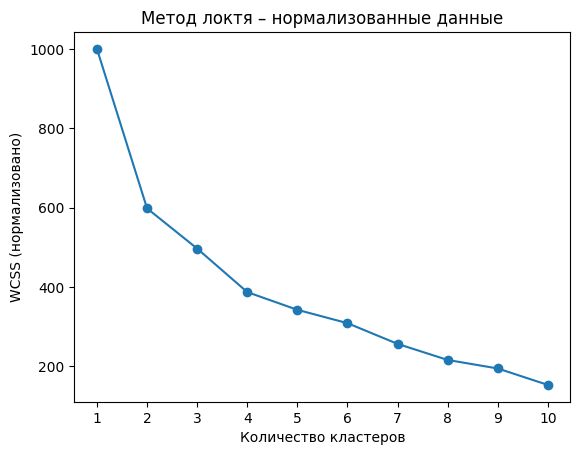

In [10]:
wcss_scaled = []
for i in range(1, 11):
    k_means = KMeans(n_clusters=i, random_state=42)
    k_means.fit(X_scaled)
    wcss_scaled.append(k_means.inertia_)

plt.plot(range(1, 11), wcss_scaled, marker='o')
plt.xticks(range(1, 11))
plt.xlabel('Количество кластеров')
plt.ylabel('WCSS (нормализовано)')
plt.title('Метод локтя – нормализованные данные')
plt.show()

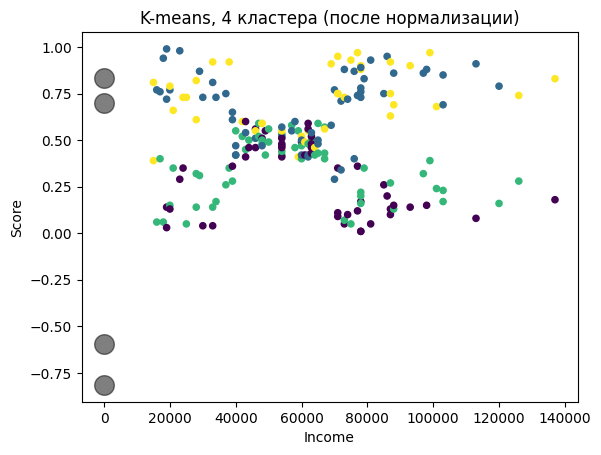

In [12]:
k_means_norm = KMeans(n_clusters=4, random_state=42).fit(X_scaled)
y_norm = k_means_norm.labels_
centers_norm = k_means_norm.cluster_centers_

# Визуализация по исходным признакам (Income, Score)
plt.scatter(x.Income, x.Score, c=y_norm, s=20, cmap='viridis')
plt.scatter(centers_norm[:, 1], centers_norm[:, 2], c='black', s=200, alpha=0.5)
plt.title('K-means, 4 кластера (после нормализации)')
plt.xlabel('Income')
plt.ylabel('Score')
plt.show()

In [13]:
X_flat = X_scaled[['Income', 'Score']]   # берём только два нормализованных признака
X_flat.head()

,Income,Score
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980


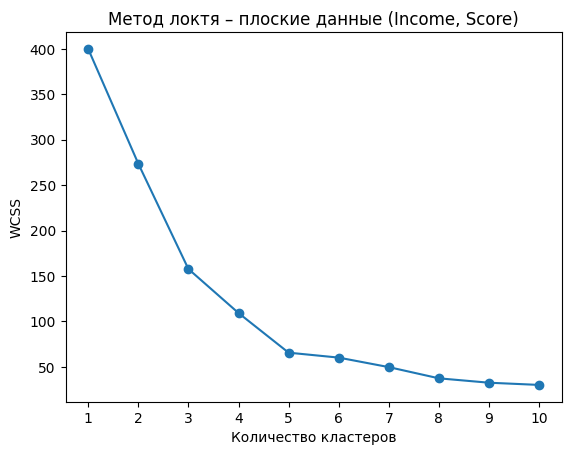

In [14]:
wcss_flat = []
for i in range(1, 11):
    k_means = KMeans(n_clusters=i, random_state=42)
    k_means.fit(X_flat)
    wcss_flat.append(k_means.inertia_)

plt.plot(range(1, 11), wcss_flat, marker='o')
plt.xticks(range(1, 11))
plt.xlabel('Количество кластеров')
plt.ylabel('WCSS')
plt.title('Метод локтя – плоские данные (Income, Score)')
plt.show()

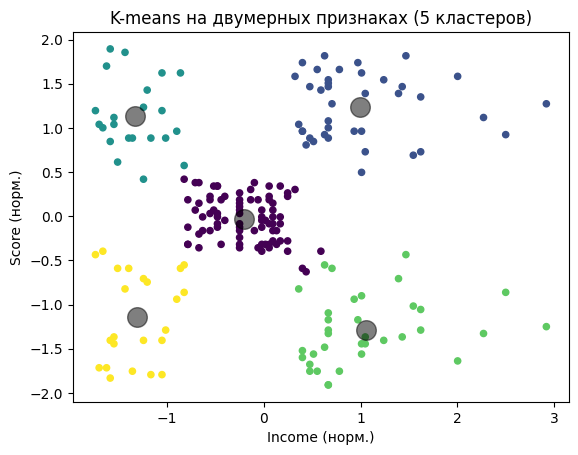

In [15]:
k_means_flat = KMeans(n_clusters=5, random_state=42).fit(X_flat)
y_flat = k_means_flat.labels_
centers_flat = k_means_flat.cluster_centers_

plt.scatter(X_flat.Income, X_flat.Score, c=y_flat, s=20, cmap='viridis')
plt.scatter(centers_flat[:, 0], centers_flat[:, 1], c='black', s=200, alpha=0.5)
plt.title('K-means на двумерных признаках (5 кластеров)')
plt.xlabel('Income (норм.)')
plt.ylabel('Score (норм.)')
plt.show()

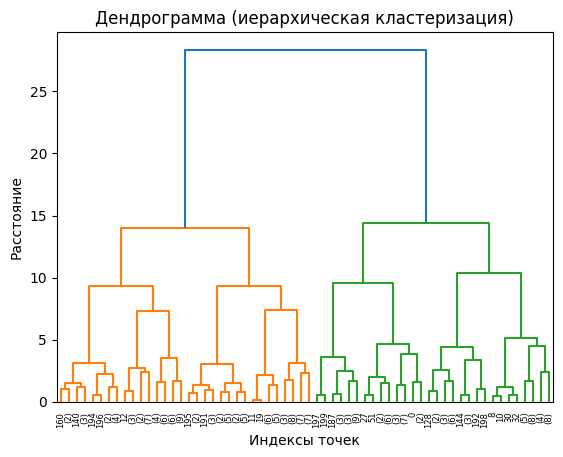

In [16]:
# Функция для построения дендрограммы (взята из методички)
def plot_dendrogram(model, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count
    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)
    dendrogram(linkage_matrix, **kwargs)

# Обучаем модель с порогом (distance_threshold) – без задания количества кластеров
agg_model = AgglomerativeClustering(distance_threshold=0, n_clusters=None)
agg_model = agg_model.fit(X_scaled)

# Рисуем дендрограмму
plot_dendrogram(agg_model, truncate_mode="level", p=5)
plt.title('Дендрограмма (иерархическая кластеризация)')
plt.xlabel('Индексы точек')
plt.ylabel('Расстояние')
plt.show()

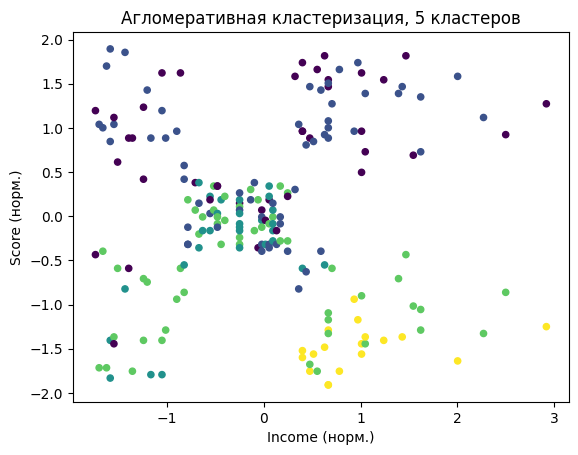

In [17]:
agg_5 = AgglomerativeClustering(n_clusters=5).fit(X_scaled)
y_agg = agg_5.labels_

plt.scatter(X_flat.Income, X_flat.Score, c=y_agg, s=20, cmap='viridis')
plt.title('Агломеративная кластеризация, 5 кластеров')
plt.xlabel('Income (норм.)')
plt.ylabel('Score (норм.)')
plt.show()

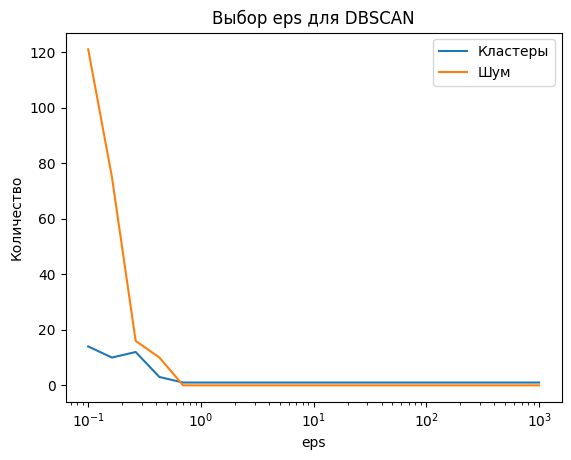

In [18]:
eps_range = np.logspace(-1, 3, 20)
clusters = []
noise = []

for eps in eps_range:
    db = DBSCAN(eps=eps, min_samples=3).fit(X_flat)
    labels = db.labels_
    n_clust = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    clusters.append(n_clust)
    noise.append(n_noise)

plt.plot(eps_range, clusters, label='Кластеры')
plt.plot(eps_range, noise, label='Шум')
plt.xscale('log')
plt.xlabel('eps')
plt.ylabel('Количество')
plt.legend()
plt.title('Выбор eps для DBSCAN')
plt.show()

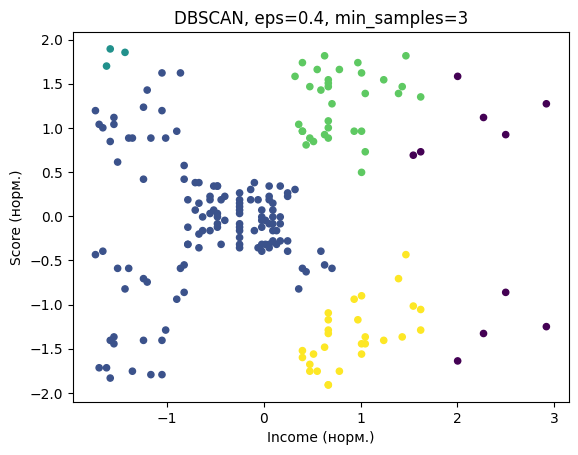

In [19]:
db_final = DBSCAN(eps=0.4, min_samples=3).fit(X_flat)
y_db = db_final.labels_

plt.scatter(X_flat.Income, X_flat.Score, c=y_db, s=20, cmap='viridis')
plt.title('DBSCAN, eps=0.4, min_samples=3')
plt.xlabel('Income (норм.)')
plt.ylabel('Score (норм.)')
plt.show()

In [20]:
for n in [3,4,5,6,7,8]:
    km = KMeans(n_clusters=n, random_state=42).fit(X_scaled)
    print(f"{n} кластеров: инерция = {km.inertia_:.2f}")

3 кластеров: инерция = 496.58
4 кластеров: инерция = 386.83
5 кластеров: инерция = 342.16
6 кластеров: инерция = 308.48
7 кластеров: инерция = 256.27
8 кластеров: инерция = 215.68


# Задания для самоятоятельного решения

# Задание 1

In [21]:
# Для KMeans с 4 кластерами на нормализованных данных (или с 5 на плоских)
# Выведем несколько строк из каждого кластера
k_means_norm = KMeans(n_clusters=4, random_state=42).fit(X_scaled)
X_clustered = X_scaled.copy()
X_clustered['Cluster'] = k_means_norm.labels_

for cluster_id in range(4):
    print(f"\n=== Кластер {cluster_id} (первые 10 записей) ===")
    print(X_clustered[X_clustered['Cluster'] == cluster_id].head(10))
    print(f"Средние значения признаков в кластере {cluster_id}:")
    print(X_clustered[X_clustered['Cluster'] == cluster_id].mean())


=== Кластер 0 (первые 10 записей) ===
         Age    Income     Score  Genre_Female  Genre_Male  Cluster
8   1.804932 -1.586321 -1.832378     -1.128152    1.128152        0
10  2.020232 -1.586321 -1.405340     -1.128152    1.128152        0
14 -0.132768 -1.548152 -1.444162     -1.128152    1.128152        0
18  0.943732 -1.433644 -0.823017     -1.128152    1.128152        0
20 -0.276302 -1.395474 -0.590088     -1.128152    1.128152        0
30  1.517865 -1.166458 -1.793556     -1.128152    1.128152        0
32  1.015499 -1.051949 -1.793556     -1.128152    1.128152        0
42  0.656665 -0.822933 -0.551266     -1.128152    1.128152        0
53  1.446099 -0.670255  0.380451     -1.128152    1.128152        0
55  0.584899 -0.670255 -0.357158     -1.128152    1.128152        0
Средние значения признаков в кластере 0:
Age             0.759830
Income          0.070868
Score          -0.814929
Genre_Female   -1.128152
Genre_Male      1.128152
Cluster         0.000000
dtype: float64

=== Кл

# Задание 2

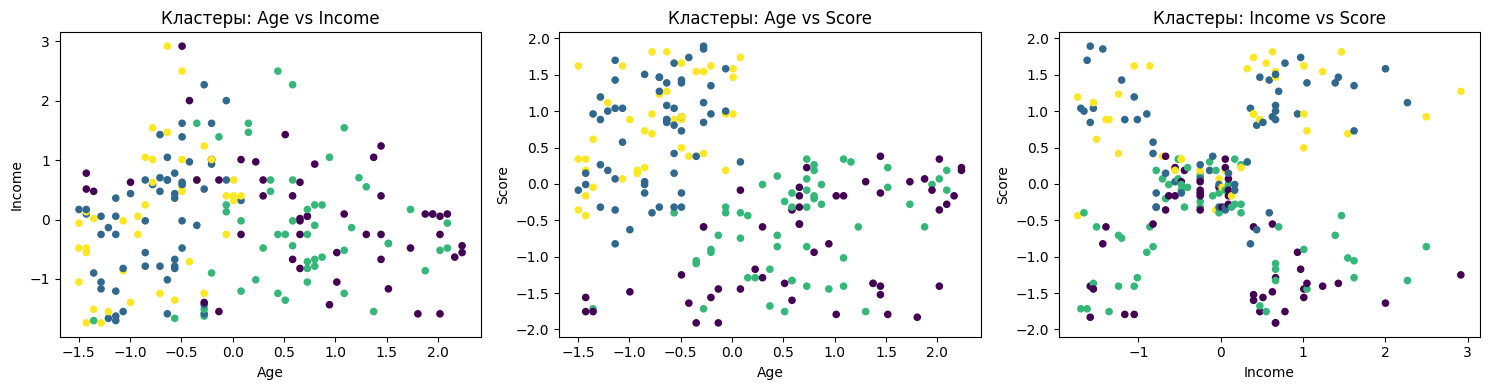

In [22]:
# Используем уже обученную модель k_means_norm (4 кластера) и разные проекции
pairs = [('Age', 'Income'), ('Age', 'Score'), ('Income', 'Score')]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (x_col, y_col) in zip(axes, pairs):
    ax.scatter(X_scaled[x_col], X_scaled[y_col], c=k_means_norm.labels_, cmap='viridis', s=20)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f'Кластеры: {x_col} vs {y_col}')
plt.tight_layout()
plt.show()

# Задание 3

Доступные колонки: ['checking_status', 'duration', 'credit_history', 'purpose', 'credit_amount', 'savings_status', 'employment', 'installment_commitment', 'personal_status', 'other_parties', 'residence_since', 'property_magnitude', 'age', 'other_payment_plans', 'housing', 'existing_credits', 'job', 'num_dependents', 'own_telephone', 'foreign_worker', 'class']


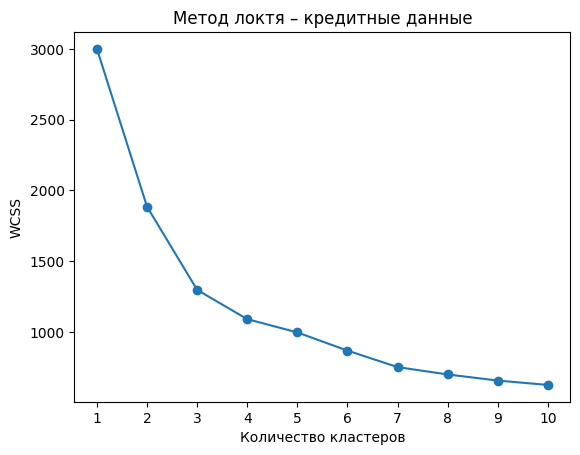

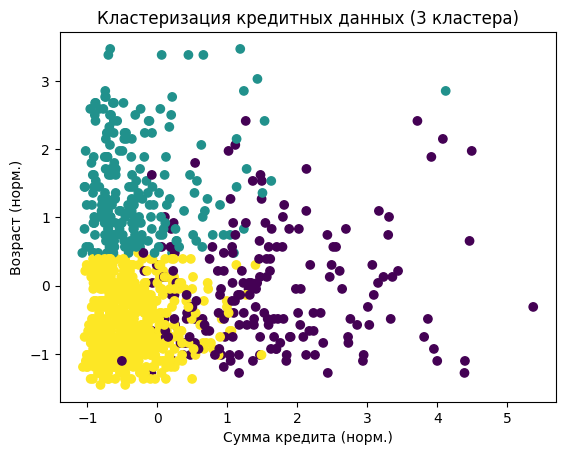

In [24]:
from sklearn.datasets import fetch_openml

# Загружаем датасет о кредитовании (немецкий)
credit = fetch_openml('credit-g', version=1, as_frame=True)
df_credit = credit.frame

# Посмотрим названия столбцов
print("Доступные колонки:", df_credit.columns.tolist())

# Выберем числовые признаки: длительность кредита, сумма кредита, возраст
num_features = ['duration', 'credit_amount', 'age']
X_credit = df_credit[num_features]

# Нормализуем
scaler_credit = StandardScaler()
X_credit_scaled = scaler_credit.fit_transform(X_credit)
X_credit_scaled = pd.DataFrame(X_credit_scaled, columns=num_features)

# Метод локтя для выбора количества кластеров
wcss_credit = []
for i in range(1, 11):
    km = KMeans(n_clusters=i, random_state=42)
    km.fit(X_credit_scaled)
    wcss_credit.append(km.inertia_)

plt.plot(range(1, 11), wcss_credit, marker='o')
plt.xticks(range(1, 11))
plt.xlabel('Количество кластеров')
plt.ylabel('WCSS')
plt.title('Метод локтя – кредитные данные')
plt.show()

# Кластеризация с выбранным числом (например, 3)
k_credit = KMeans(n_clusters=3, random_state=42).fit(X_credit_scaled)
y_credit = k_credit.labels_

# Визуализация в двух признаках (credit_amount vs age)
plt.scatter(X_credit_scaled['credit_amount'], X_credit_scaled['age'], c=y_credit, cmap='viridis')
plt.xlabel('Сумма кредита (норм.)')
plt.ylabel('Возраст (норм.)')
plt.title('Кластеризация кредитных данных (3 кластера)')
plt.show()

# Задание 4

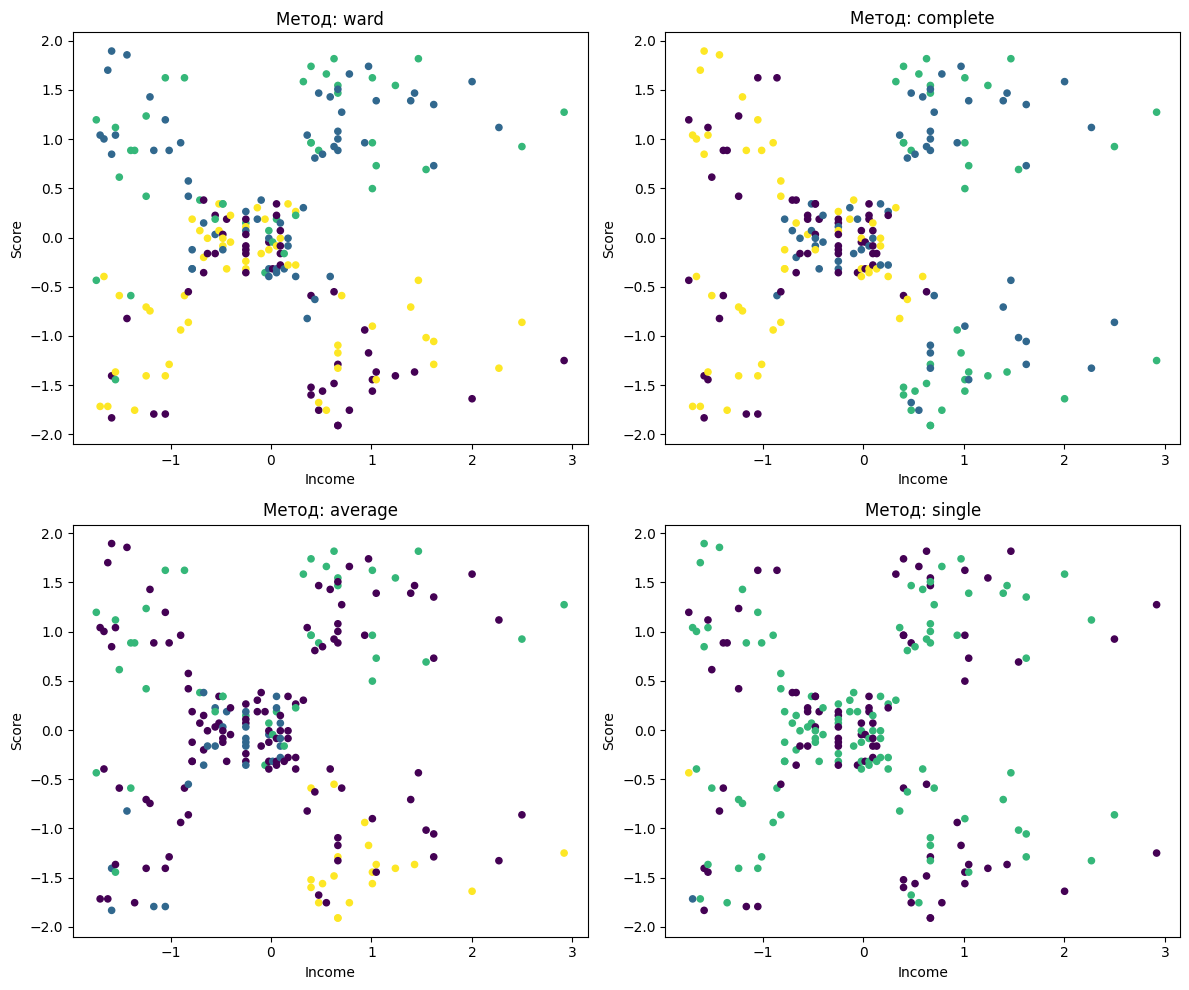

In [25]:
from sklearn.cluster import AgglomerativeClustering

methods = ['ward', 'complete', 'average', 'single']
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for i, method in enumerate(methods):
    agg = AgglomerativeClustering(n_clusters=4, linkage=method).fit(X_scaled)
    labels = agg.labels_
    axes[i].scatter(X_flat.Income, X_flat.Score, c=labels, cmap='viridis', s=20)
    axes[i].set_title(f'Метод: {method}')
    axes[i].set_xlabel('Income')
    axes[i].set_ylabel('Score')
plt.tight_layout()
plt.show()

# Задание 5

In [26]:
from sklearn.metrics import pairwise_distances

def wcss_dbscan(X, labels):
    wcss = 0
    for label in set(labels):
        if label != -1:
            points = X[labels == label]
            center = points.mean(axis=0)
            wcss += np.sum(pairwise_distances(points, [center])**2)
    return wcss

# KMeans (5 кластеров) на плоских данных
kmeans_flat = KMeans(n_clusters=5, random_state=42).fit(X_flat)
print(f"KMeans WCSS: {kmeans_flat.inertia_:.2f}")

# DBSCAN
db = DBSCAN(eps=0.4, min_samples=3).fit(X_flat)
labels_db = db.labels_
print(f"DBSCAN WCSS (без шума): {wcss_dbscan(X_flat.values, labels_db):.2f}")
print(f"Количество кластеров DBSCAN: {len(set(labels_db)) - (1 if -1 in labels_db else 0)}")

KMeans WCSS: 65.57
DBSCAN WCSS (без шума): 128.74
Количество кластеров DBSCAN: 4


# Задание 6

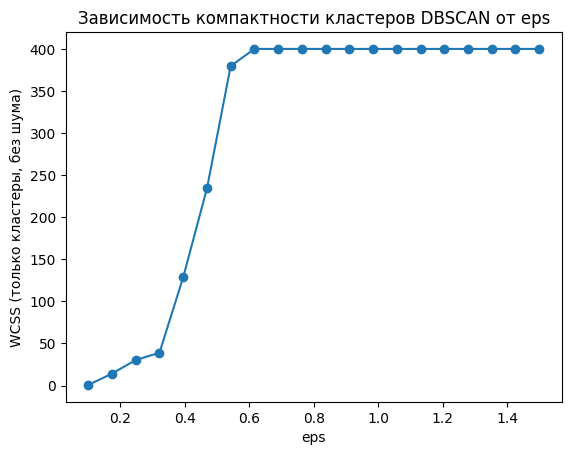

In [27]:
eps_values = np.linspace(0.1, 1.5, 20)
wcss_db = []

for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=3).fit(X_flat)
    labels = db.labels_
    wcss = wcss_dbscan(X_flat.values, labels)
    wcss_db.append(wcss)

plt.plot(eps_values, wcss_db, marker='o')
plt.xlabel('eps')
plt.ylabel('WCSS (только кластеры, без шума)')
plt.title('Зависимость компактности кластеров DBSCAN от eps')
plt.show()